## Basic Setup

In [1]:
import os
import random
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from keras.layers import BatchNormalization
from keras.optimizers import SGD
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

os.chdir('../../../../') # move four level up to the base path
from src.utils import load_and_preprocess_images
from src.model_evaluation import evaluate_model, plot_history

In [2]:
# set the random seeds to make sure that the results are reproducible
SEED = 1234
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

In [3]:
model_name = '0_real_eyes'
transfer_learning_stage = '1_full_network'
repo_path = '/Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection'

realDataPath = repo_path + '/data/CEW_Data_Test_Train'
realTrainingPath = realDataPath + '/TrainingSet'
realTestPath = realDataPath + '/TestSet'

In [4]:
comment = "evening run"
model_file_path = repo_path + f"/models/cnn/{model_name}/{transfer_learning_stage}/weights/{comment}_model.keras"
ckpt_file_path = repo_path + f"/models/cnn/{model_name}/{transfer_learning_stage}/ckpt/{comment}_checkpoint.model.keras"
history_file_path = repo_path + f"/models/cnn/{model_name}/{transfer_learning_stage}/history/{comment}_history.csv"
assert not os.path.exists(ckpt_file_path), "Model already exists. Please change the comment."

In [5]:
# Hyperparameters
BATCH_SIZE = 64
IMAGE_SIZE = (224, 224)
INPUT_SHAPE = IMAGE_SIZE + (3,)

DATA_AUG_RATE = 0.1
LOSS_FUNCTION = 'sparse_categorical_crossentropy'

FT_EPOCHS = 100
FT_LEARNING_RATE = 0.00001
OPTIMIZER = SGD(learning_rate=FT_LEARNING_RATE)

In [6]:
early_stop = EarlyStopping(monitor="val_accuracy", mode="max", patience=20, start_from_epoch=10)
checkpoint = ModelCheckpoint(ckpt_file_path, monitor="val_accuracy", mode="max", save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=10, min_lr=0.00001, verbose=1)

In [7]:
real_train_data = load_and_preprocess_images(realTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, data_aug_rate=DATA_AUG_RATE, subset='training', validation_split=0.2)
real_valid_data = load_and_preprocess_images(realTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, subset='validation', validation_split=0.2)
real_test_data = load_and_preprocess_images(realTestPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, shuffle=False)

Found 3876 files belonging to 2 classes.
Using 3101 files for training.
Found 3876 files belonging to 2 classes.
Using 775 files for validation.
Found 970 files belonging to 2 classes.


## Finetuning the Pre-Trained Model

In [8]:
# define the path to the pretrained model
pretrained_model_path = repo_path + '/models/cnn/0_real_eyes/0_last_layers/weights/afternoon run_model.keras'

# load the model with compiling
model = tf.keras.models.load_model(pretrained_model_path, compile=True)

# get benchmark results by evaluating the model on the test set
evaluate_model(model, real_test_data)

16/16 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.9392 - loss: 6.8769
Test loss: 6.88734245300293
Test accuracy: 0.929896891117096


In [9]:
# load and override the model again without compiling it
model = tf.keras.models.load_model(pretrained_model_path, compile=False)

# unfreeze all layers which are not BN layers
for layer in model.layers:
    if isinstance(layer, BatchNormalization): # freeze BN layers
        layer.trainable = False
    else: # unfreeze all other layers
        layer.trainable = True

# display the summary if needed
# pretrained_model.summary(show_trainable=True)

In [10]:
# compile the model with the same optimizer and loss function
model.compile(loss=LOSS_FUNCTION, optimizer=OPTIMIZER, metrics=['accuracy'])

# train the entire model with the same data but lower learning rate
history = model.fit(
    real_train_data,
    validation_data=real_valid_data,
    epochs=FT_EPOCHS,
    callbacks=[checkpoint, reduce_lr] # early_stop
    )

Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9307 - loss: 6.8646
Epoch 1: val_accuracy improved from -inf to 0.91226, saving model to /Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection/models/cnn/0_real_eyes/1_full_network/ckpt/evening run_checkpoint.model.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 277s 6s/step - accuracy: 0.9307 - loss: 6.8647 - val_accuracy: 0.9123 - val_loss: 6.9157 - learning_rate: 1.0000e-05
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9291 - loss: 6.8775
Epoch 2: val_accuracy improved from 0.91226 to 0.92645, saving model to /Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection/models/cnn/0_real_eyes/1_full_network/ckpt/evening run_checkpoint.model.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 210s 4s/step - accuracy: 0.9292 - loss: 6.8773 - val_accuracy: 0.9265 - val_loss: 6.8850 - learning_rate: 1.0000e-05
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9397 - loss: 6.8688
Epoch 3: val_ac

In [11]:
# save the history
history_df = pd.DataFrame(history.history)
history_df['epoch'] = history.epoch
history_df.to_csv(history_file_path, index=False)

In [12]:
# load the best model
model.load_weights(ckpt_file_path)

In [13]:
# save the model
model.save(model_file_path)

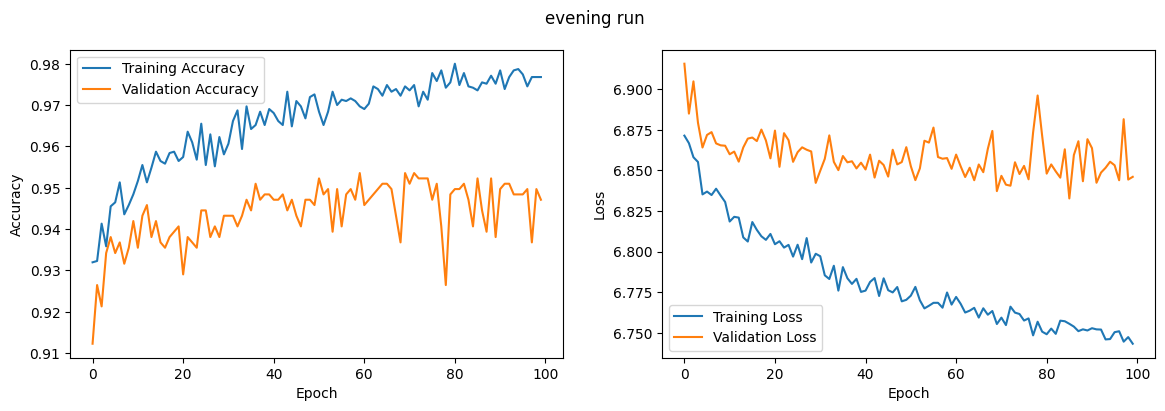

Best train_accuracy: 0.98
Best train_loss: 6.7433
Best val_accuracy: 0.9535
Best val_loss: 6.8327
Last improvement at epoch: 60


In [14]:
plot_history(comment=comment, history=history)

In [15]:
evaluate_model(model, real_test_data)

16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.9574 - loss: 6.8183
Test loss: 6.835954666137695
Test accuracy: 0.9474226832389832
